# 3장 2강: 피어슨 상관계수의 의미와 한계 — 실습문제

## 실습 목표

- 두 연속형 변수의 피어슨 상관계수와 p-value를 계산하고 방향·강도를 해석합니다.
- 결정계수 $r^2$의 의미를 올바르게 설명합니다.
- 산점도를 함께 확인하여 이상치와 비선형 관계가 피어슨 상관계수에 미치는 영향을 판단합니다.
- 상관관계만으로 인과관계를 주장할 수 없는 이유와 가능한 혼란변수를 설명합니다.

## 실습 환경 / 데이터

- Python, pandas, NumPy, SciPy, Matplotlib
- `ames_housing.csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `LotArea`
- 모든 판단은 유의수준 $\alpha=0.05$를 기준으로 합니다.

## 실습 준비

아래 셀을 실행해 데이터를 불러오고 크기, 결측치, 컬럼을 확인하세요.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

data_candidates = [
    Path("ames_housing.csv"),
    Path("upload/ames_housing.csv"),]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("ames_housing CSV 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)
alpha = 0.05

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()


데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


In [2]:
# 피어슨 상관계수 : 두 숫자형 변수의 선형 관계를 -1 ~ +1 로 나타내는 지표
# -> 한 달의 광고비와 그 달 매출을 한쌍으로 묶어 선형 관계로 표현

# 양의 상관 : 같은 방향으로 움직인다
# -> x가 증가할 때 y도 함께 증가
# 공부량 : 성적

# 음의 상관 : 반대 방향으로 움직인다.
# -> x가 증가할 때 y는 감소 혹은 반대
# 기온 : 난방비

# 결정계수(R^2)
# -> R^2이 0.95면 이 모델은 데이터에 대한 설명력을 95%정도 가지고 있다.
# 1에 가까워질수록 좋다. 

# 상관관계 : 두 변수가 함께 달라지는 통계적 관계
# -> 광고 노출이 많은 날 주문도 많다라는 것은 상관관계가 있다라고 볼 수 있다.

# 인과관계 : 어떤 조건을 바꿨을 때 그 변화 때문에 결과가 달라지는 관계
# -> 다른 조건을 같게 설정한 뒤 광고 노출을 기존과 다르게 하여 주문량이 실제로 달라지는 것을 확인

---

## 필수 1. 생활면적과 매매가격의 피어슨 상관분석

`GrLivArea`와 `SalePrice`의 선형 관계를 분석하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. `stats.pearsonr()`로 피어슨 상관계수 $r$과 p-value를 계산하세요.
3. $r^2$을 계산하세요.
4. 축 이름과 제목이 있는 산점도를 그리세요.
5. 아래 질문에 문장으로 답하세요.

### 질문

- 상관관계의 방향과 강도는 어떠한가요?
- p-value를 기준으로 선형 상관관계가 통계적으로 유의한가요?
- $r^2$은 이 관계에서 무엇을 의미하나요?
- 이 결과만으로 생활면적 증가가 매매가격 상승의 원인이라고 말할 수 있나요?


**Q1.** 상관관계의 방향과 강도는 어떠한가요?
- 강한 양의 상관관계가 있다 약 0.71

**Q2.** p-value를 기준으로 선형 상관관계가 통계적으로 유의한가요?
- 네, p-value가 0.05보다 작으므로 상관계수가 0일 것 이라는 귀무가설을 기각한다.

**Q3.** $r^2$은 이 관계에서 무엇을 의미하나요?
- 같은 자료에 생활면적을 설명변수로 하는 절편을 포함하여 최소제곱 단순 선형회귀를 적합하여 결정계수 r^2이 약 0.50이다
- 즉, 생활면적을 이용한 직선 모형이 이자료의 가격 변동을 약 50.2% 설명한다.

**Q4.** 이 결과만으로 생활면적 증가가 매매가격 상승의 원인이라고 말할 수 있나요?
- 아니오. 상관관계가 아무리 높아도 인과성이 성립하지 않는다.
- 이미 존재하는 주택의 특성을 관찰한 데이터에서 다른 외부 요인 변수를 분리하여 확인하지 못했다.

=== 피어슨 상관분석 결과 ===
표본 수 (n)        : 1460
피어슨 상관계수 (r): 0.7086
p-value            : 4.5180e-223
결정계수 (r^2)     : 0.5021


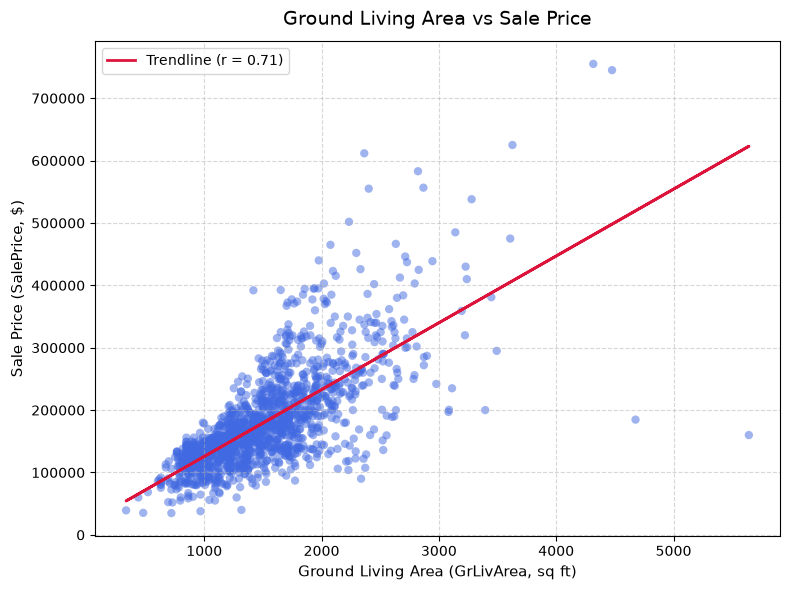

In [3]:
# 여기에 코드를 작성하세요.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# 1. 두 변수의 결측치를 제거한 분석용 데이터 생성
clean_data = df[["GrLivArea", "SalePrice"]].dropna()
x = clean_data["GrLivArea"]
y = clean_data["SalePrice"]

# 2. 피어슨 상관계수(r)와 p-value 계산
r, p_value = stats.pearsonr(x, y)

# 3. 결정계수 (r^2) 계산
r_squared = r**2

print("=== 피어슨 상관분석 결과 ===")
print(f"표본 수 (n)        : {len(clean_data)}")
print(f"피어슨 상관계수 (r): {r:.4f}")
print(f"p-value            : {p_value:.4e}")
print(f"결정계수 (r^2)     : {r_squared:.4f}")

# 4. 산점도(Scatter Plot) 시각화
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.5, color="royalblue", edgecolors="none")
plt.title("Ground Living Area vs Sale Price", fontsize=14, pad=12)
plt.xlabel("Ground Living Area (GrLivArea, sq ft)", fontsize=11)
plt.ylabel("Sale Price (SalePrice, $)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

# 회귀 추세선 추가
m, b = np.polyfit(x, y, 1)
plt.plot(
    x,
    m * x + b,
    color="crimson",
    linewidth=2,
    label=f"Trendline (r = {r:.2f})",
)
plt.legend()
plt.tight_layout()
plt.show()


---

## 필수 2. 피어슨 상관계수의 두 가지 한계 확인

피어슨 상관계수가 이상치에 민감하고 비선형 관계를 놓칠 수 있다는 점을 확인하세요.

### A. 이상치의 영향

1. `GrLivArea`, `SalePrice`에서 `random_state=42`로 50행을 표본 추출하세요.
2. 표본의 $r$과 p-value를 계산하세요.
3. 학습용 가상 이상치 `(GrLivArea=6000, SalePrice=50000)` 한 행을 표본에만 추가하세요. 원본 `df`는 변경하지 마세요.
4. 이상치 추가 후 $r$과 p-value를 다시 계산하세요.
5. 추가 전후 산점도를 나란히 그리고 결과를 비교하세요.

### B. 비선형 관계

1. `x = [-3, -2, -1, 0, 1, 2, 3]`, `y = x**2`를 만드세요.
2. $x$와 $y$의 $r$과 p-value를 계산하고 산점도를 그리세요.

### 질문

- 이상치 추가 전후 $r$과 유의성 판단은 어떻게 달라졌나요?
- 이 결과는 왜 산점도를 함께 확인해야 함을 보여주나요?
- $y=x^2$는 분명한 관계인데도 $r$이 0에 가까운 이유는 무엇인가요?
- `r ≈ 0`을 “두 변수 사이에 아무 관계도 없다”로 해석해도 되나요?


**Q1.** 이상치 추가 전후 $r$과 유의성 판단은 어떻게 달라졌나요?
- r은 0.71 -> 0.26으로 감소했다. 
- p-value는 0.05 미만에서 0.06으로 증가했다.
- 귀무가설을 기각함에서 귀무가설을 기각할 수 없음으로 판단이 변경

**Q2.** 이 결과는 왜 산점도를 함께 확인해야 함을 보여주나요?
- 요약값(계산된 수치)만 보면 변화의 원인을 한 눈에 파악하기 어려움
- 산점도는 멀리 떨어진 점들과 일부 선형관계를 한 눈에 파악하기 쉬움
- 이상치도 한눈에 파악하기 쉽다.

**Q3.** $y=x^2$는 분명한 관계인데도 $r$이 0에 가까운 이유는 무엇인가요?
- 피어슨 r은 직선형태의 관계를 요약함
- u자형 그래프의 왼쪽과 오른쪽은 서로 반대 방향의 선형 움직임을 보이기 떄문

**Q4.** `r ≈ 0`을 “두 변수 사이에 아무 관계도 없다”로 해석해도 되나요?
- 아니오. r ≈ 0dms 선형관계가 거의 없다는 뜻이며, 비선형 관계는 존재할 수 있다.

=== Part A. 이상치 영향 분석 결과 ===
이상치 추가 전 (n=50) : r = 0.7059, p-value = 1.0263e-08
이상치 추가 후 (n=51) : r = 0.2602, p-value = 6.5137e-02


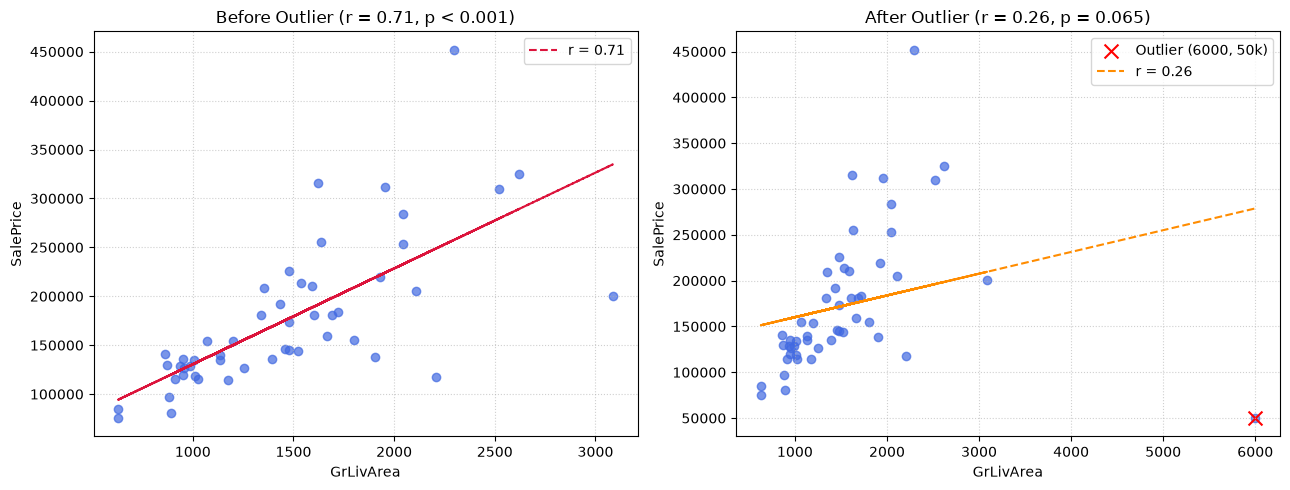


=== Part B. 비선형 관계 분석 결과 ===
피어슨 상관계수 (r): 0.0000
p-value            : 1.0000


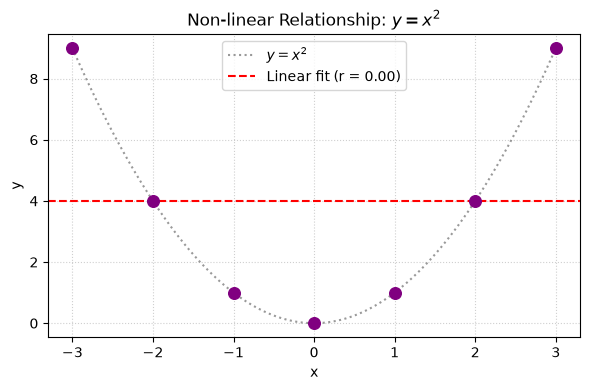

In [4]:
# 여기에 코드를 작성하세요.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# =========================================================
# Part A. 이상치의 영향
# =========================================================
# 1. 50행 표본 추출 (원본 df 보존)
sample_a = (
    df[["GrLivArea", "SalePrice"]].dropna().sample(n=50, random_state=42).copy()
)

# 2. 이상치 추가 전 r 및 p-value 계산
r_orig, p_orig = stats.pearsonr(sample_a["GrLivArea"], sample_a["SalePrice"])

# 3. 학습용 가상 이상치 (GrLivArea=6000, SalePrice=50000) 추가
outlier = pd.DataFrame([{"GrLivArea": 6000, "SalePrice": 50000}])
sample_outlier = pd.concat([sample_a, outlier], ignore_index=True)

# 4. 이상치 추가 후 r 및 p-value 재계산
r_out, p_out = stats.pearsonr(
    sample_outlier["GrLivArea"], sample_outlier["SalePrice"]
)

print("=== Part A. 이상치 영향 분석 결과 ===")
print(f"이상치 추가 전 (n=50) : r = {r_orig:.4f}, p-value = {p_orig:.4e}")
print(f"이상치 추가 후 (n=51) : r = {r_out:.4f}, p-value = {p_out:.4e}")

# 5. 추가 전후 산점도 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (좌) 이상치 추가 전
axes[0].scatter(
    sample_a["GrLivArea"], sample_a["SalePrice"], color="royalblue", alpha=0.7
)
m_orig, b_orig = np.polyfit(sample_a["GrLivArea"], sample_a["SalePrice"], 1)
axes[0].plot(
    sample_a["GrLivArea"],
    m_orig * sample_a["GrLivArea"] + b_orig,
    color="crimson",
    linestyle="--",
    label=f"r = {r_orig:.2f}",
)
axes[0].set_title(
    f"Before Outlier (r = {r_orig:.2f}, p < 0.001)", fontsize=12
)
axes[0].set_xlabel("GrLivArea")
axes[0].set_ylabel("SalePrice")
axes[0].legend()
axes[0].grid(True, linestyle=":", alpha=0.6)

# (우) 이상치 추가 후
axes[1].scatter(
    sample_outlier["GrLivArea"],
    sample_outlier["SalePrice"],
    color="royalblue",
    alpha=0.7,
)
axes[1].scatter(
    [6000], [50000], color="red", s=100, marker="x", label="Outlier (6000, 50k)"
)
m_out, b_out = np.polyfit(
    sample_outlier["GrLivArea"], sample_outlier["SalePrice"], 1
)
axes[1].plot(
    sample_outlier["GrLivArea"],
    m_out * sample_outlier["GrLivArea"] + b_out,
    color="darkorange",
    linestyle="--",
    label=f"r = {r_out:.2f}",
)
axes[1].set_title(f"After Outlier (r = {r_out:.2f}, p = {p_out:.3f})", fontsize=12)
axes[1].set_xlabel("GrLivArea")
axes[1].set_ylabel("SalePrice")
axes[1].legend()
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# =========================================================
# Part B. 비선형 관계
# =========================================================
# 1. x, y 데이터 생성
x_nonlin = np.array([-3, -2, -1, 0, 1, 2, 3])
y_nonlin = x_nonlin**2

# 2. r과 p-value 계산
r_nonlin, p_nonlin = stats.pearsonr(x_nonlin, y_nonlin)

print("\n=== Part B. 비선형 관계 분석 결과 ===")
print(f"피어슨 상관계수 (r): {r_nonlin:.4f}")
print(f"p-value            : {p_nonlin:.4f}")

# 산점도 시각화
plt.figure(figsize=(6, 4))
plt.scatter(x_nonlin, y_nonlin, color="purple", s=70, zorder=3)
x_curve = np.linspace(-3, 3, 100)
plt.plot(
    x_curve,
    x_curve**2,
    color="gray",
    linestyle=":",
    alpha=0.8,
    label="$y = x^2$",
)
plt.axhline(
    y=np.mean(y_nonlin),
    color="red",
    linestyle="--",
    label=f"Linear fit (r = {r_nonlin:.2f})",
)
plt.title("Non-linear Relationship: $y = x^2$", fontsize=12)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


---

## 과제. 대지면적과 매매가격의 관계를 근거 있게 보고하기

`LotArea`와 `SalePrice`의 관계를 분석하고, 상관과 인과를 구별한 짧은 분석 보고를 작성하세요.

### 수행 요구사항

1. 두 변수의 피어슨 상관계수, p-value, $r^2$을 계산하세요.
2. 산점도를 그려 관계의 형태와 이상치 여부를 확인하세요.
3. 유의수준 0.05에서 통계적 유의성을 판단하세요.
4. 아래 질문에 빠짐없이 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 관계의 방향과 강도는 어떠한가요?
- 통계적으로 유의한 결과와 강한 관계는 같은 의미인가요?
- 대지면적이 넓어지면 매매가격이 오른다는 인과결론을 내릴 수 있나요?
- 두 변수에 함께 영향을 줄 수 있는 혼란변수를 두 가지 이상 제시하세요.
- 피어슨 상관계수가 0에 가까우면 두 변수 사이에 아무 관계도 없다고 판단해도 되나요? U자형 관계를 예로 들어 설명하세요.

In [ ]:
# 여기에 코드를 작성하세요.


## 실습 마무리

**1.** 어떤 문제가 있었는가?
- 상관계수와 p-value만으로는 관계를 명확하게 규정하기 어려움

**2.** 어떻게 개선했는가?
- r, r^2, p-value, 산점도, 이상치 유 / 무를 함께 확인하고 비교한다.

**3.** 무엇을 근거로 개선되었다고 판단했는가?
- 이상치 값 하나로 r값과 p-value가 달라지는 것을 확인했다.
- 본 데이터의 이상치를 제거한다면 정상적인 r값과 p-value로 올바른 통계적 해석이 가능하다.

**4.** 피어슨 상관계수의 숫자만 보았을 때 놓칠 수 있었던 점, 산점도와 인과적 관점을 추가해 해석이 어떻게 개선되었는지 정리하세요.